# Model Comparison

## Objective

Compare the performance of all implemented super-resolution models.

The comparison includes:

- Number of trainable parameters
- Average PSNR
- Average SSIM
- Average MSE

The evaluated methods are:

- Bicubic interpolation (visual baseline)
- SRCNN
- FSRCNN
- Convolutional Autoencoder

The goal is to identify the most suitable architecture for retro videogame image super-resolution.

In [6]:
import pandas as pd

In [7]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [8]:
import torch

from src.models.srcnn import SRCNN
from src.models.fsrcnn import FSRCNN
from src.models.autoencoder import ConvAutoencoder

In [9]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


srcnn = SRCNN()
fsrcnn = FSRCNN()
autoencoder = ConvAutoencoder()

print(f"SRCNN        : {count_parameters(srcnn):,}")
print(f"FSRCNN       : {count_parameters(fsrcnn):,}")
print(f"Autoencoder  : {count_parameters(autoencoder):,}")

SRCNN        : 20,099
FSRCNN       : 15,275
Autoencoder  : 1,110,403


The Convolutional Autoencoder achieved the best reconstruction quality (highest PSNR and SSIM, lowest MSE), at the cost of a significantly larger number of trainable parameters compared to SRCNN and FSRCNN.

In [10]:
import pandas as pd

results = {

    "Model": [
        "SRCNN",
        "FSRCNN",
        "ConvAutoencoder"
    ],

    "Trainable Parameters": [
        20099,
        15275,
        1110403
    ],

    "PSNR (dB)": [
        28.27,
        27.26,
        29.33
    ],

    "SSIM": [
        0.8851,
        0.8480,
        0.8947
    ],

    "MSE": [
        0.001622,
        0.001988,
        0.001249
    ]

}

comparison = pd.DataFrame(results)

comparison

,Model,Trainable Parameters,PSNR (dB),SSIM,MSE
0,SRCNN,20099,28.27,0.8851,0.001622
1,FSRCNN,15275,27.26,0.8480,0.001988
2,ConvAutoencoder,1110403,29.33,0.8947,0.001249


In [11]:
comparison

,Model,Trainable Parameters,PSNR (dB),SSIM,MSE
0,SRCNN,20099,28.27,0.8851,0.001622
1,FSRCNN,15275,27.26,0.8480,0.001988
2,ConvAutoencoder,1110403,29.33,0.8947,0.001249


In [12]:
import matplotlib.pyplot as plt

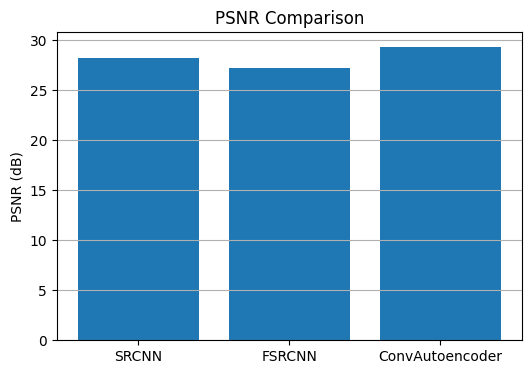

In [13]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["PSNR (dB)"]
)

plt.ylabel("PSNR (dB)")
plt.title("PSNR Comparison")

plt.grid(axis="y")

plt.show()

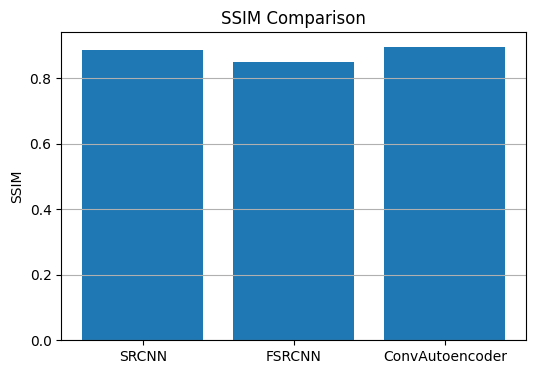

In [14]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["SSIM"]
)

plt.ylabel("SSIM")
plt.title("SSIM Comparison")

plt.grid(axis="y")

plt.show()

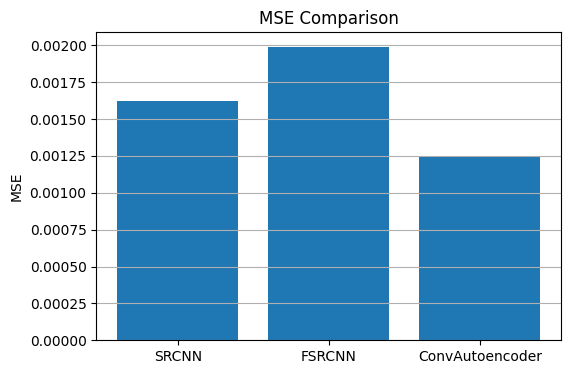

In [15]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["MSE"]
)

plt.ylabel("MSE")
plt.title("MSE Comparison")

plt.grid(axis="y")

plt.show()

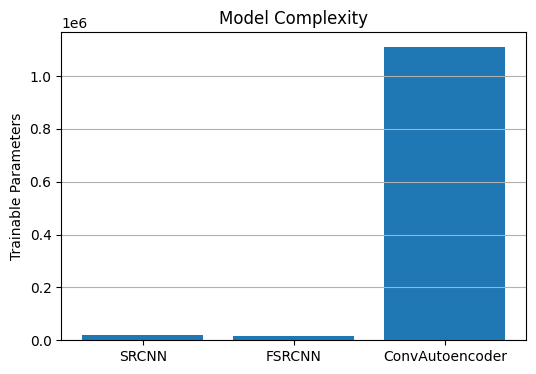

In [17]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Trainable Parameters"]
)

plt.ylabel("Trainable Parameters")
plt.title("Model Complexity")

plt.grid(axis="y")

plt.show()

In [18]:
best_model = comparison.loc[
    comparison["PSNR (dB)"].idxmax(),
    "Model"
]

print("=" * 40)
print(f"Best performing model: {best_model}")
print("=" * 40)

Best performing model: ConvAutoencoder


## Conclusions

Three deep learning models were evaluated for single-image super-resolution:

- SRCNN
- FSRCNN
- Convolutional Autoencoder

According to the obtained results, the Convolutional Autoencoder achieved the best reconstruction quality on the validation dataset.

Compared with SRCNN and FSRCNN, it obtained:

- the highest PSNR;
- the highest SSIM;
- the lowest MSE.

The main drawback is the larger number of trainable parameters, making it computationally heavier than SRCNN and FSRCNN.

Nevertheless, considering the quality of the reconstructed retro videogame screenshots, the Convolutional Autoencoder represents the best overall compromise among the evaluated approaches.